# Notebook 2: Training Dynamics from Scratch

## From Scalar Autograd to Real Matrix-Based Networks

In Notebook 1, we built a scalar autograd engine — the `Value` class — and used it to train
a tiny MLP on a 2D toy dataset. That was great for understanding the *mechanics* of
backpropagation, but real neural networks don't operate on individual scalars. They operate
on **matrices** of activations and weights, leveraging NumPy's (or PyTorch's/JAX's) optimized
linear algebra routines for speed.

In this notebook, we move from "scalar autograd as a learning tool" to **real matrix-based
neural networks** implemented entirely in NumPy. We will:

1. **Build a matrix-based MLP** with manual forward pass, cross-entropy loss, and full
   backpropagation — all in NumPy matrix form.
2. **Train on MNIST digits** — a real image classification task.
3. **Run experiments** that reveal deep truths about how neural networks actually learn:
   - Why **initialization** (He vs Xavier vs naive) matters enormously
   - Why **vanishing gradients** plagued early deep learning
   - Why **overparameterized** models generalize despite having far more parameters than data
   - What the **loss landscape** actually looks like

### Curriculum Points Covered

| # | Concept | Where |
|---|---------|-------|
| ③ | Overparameterization helps | Section 6 |
| ⑥ | Geometry matters (loss landscape) | Section 7 |
| ⑦ | Capacity ≠ performance | Sections 4 & 5 |

**Prerequisites:** Notebook 1 (scalar autograd, backprop basics, chain rule).
**Tools:** Python + NumPy + matplotlib + sklearn (data loading only). No PyTorch.


---
## 2. Matrix-Based MLP in NumPy

### Why matrices?

In Notebook 1, each weight was a `Value` object and gradients flowed through individual scalar
operations. That's pedagogically perfect but computationally slow. Real networks compute
$\mathbf{h} = \sigma(\mathbf{W}\mathbf{x} + \mathbf{b})$ as a single matrix multiply, which
NumPy (and GPU libraries) can execute orders of magnitude faster.

### The plan

We'll implement:
- **Forward pass:** matrix multiplications + activation functions
- **Cross-entropy loss:** the standard loss for classification
- **Backward pass:** manual gradient computation using matrix calculus
- **SGD with momentum:** a simple but effective optimizer

All layer operations follow this pattern for a layer $l$:

$$\mathbf{z}^{(l)} = \mathbf{W}^{(l)} \mathbf{a}^{(l-1)} + \mathbf{b}^{(l)}$$
$$\mathbf{a}^{(l)} = \sigma(\mathbf{z}^{(l)})$$

where $\mathbf{a}^{(0)} = \mathbf{x}$ is the input.


### 2.1 Activation Functions and Their Derivatives

Before building the network, let's implement our activation functions. We need both the
function *and* its derivative for backpropagation.


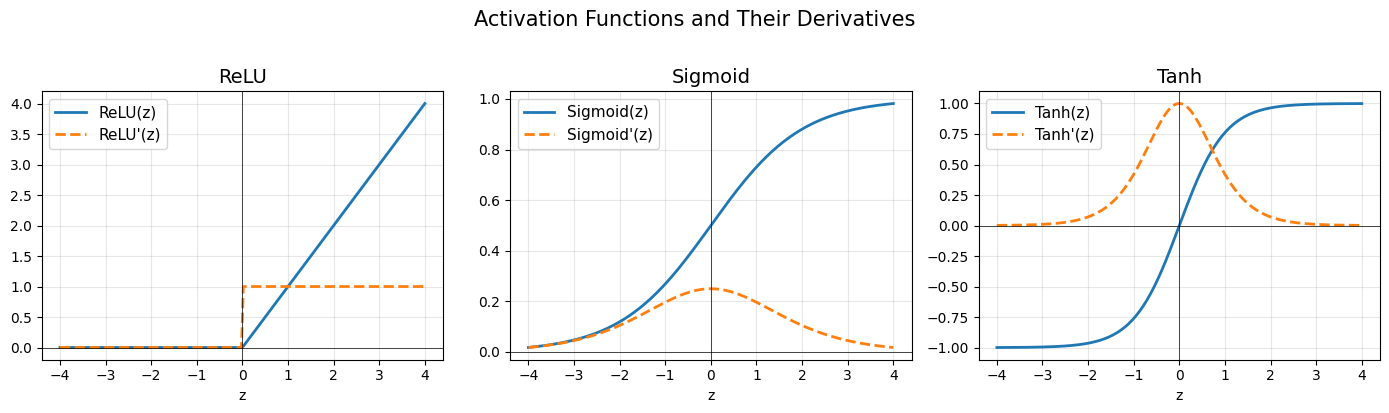

Notice: Sigmoid derivative peaks at 0.25 -- this is why gradients vanish in deep sigmoid nets!
ReLU derivative is exactly 0 or 1 -- gradients flow unchanged through active neurons.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Reproducibility
np.random.seed(42)

# --- Activation functions ---
# Each returns the activation value. Derivatives are separate functions for backprop.

def relu(z):
    """ReLU: max(0, z). Derivative is 0 or 1."""
    return np.maximum(0, z)

def relu_deriv(z):
    """Derivative of ReLU w.r.t. its input z."""
    return (z > 0).astype(float)

def sigmoid(z):
    """Sigmoid: 1/(1+exp(-z)). Numerically stable version."""
    z_safe = np.clip(z, -500, 500)
    return 1.0 / (1.0 + np.exp(-z_safe))

def sigmoid_deriv(z):
    """Derivative of sigmoid: sig(z) * (1 - sig(z))."""
    s = sigmoid(z)
    return s * (1.0 - s)

def tanh_act(z):
    """Tanh activation."""
    return np.tanh(z)

def tanh_deriv(z):
    """Derivative of tanh: 1 - tanh(z)^2."""
    t = np.tanh(z)
    return 1.0 - t ** 2

# Quick visual check
z = np.linspace(-4, 4, 200)
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, fn, dfn, name in [
    (axes[0], relu, relu_deriv, "ReLU"),
    (axes[1], sigmoid, sigmoid_deriv, "Sigmoid"),
    (axes[2], tanh_act, tanh_deriv, "Tanh"),
]:
    ax.plot(z, fn(z), label=f"{name}(z)", linewidth=2)
    ax.plot(z, dfn(z), '--', label=f"{name}'(z)", linewidth=2)
    ax.set_title(name, fontsize=14)
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3)
    ax.axhline(0, color='k', linewidth=0.5)
    ax.axvline(0, color='k', linewidth=0.5)
    ax.set_xlabel("z")

plt.suptitle("Activation Functions and Their Derivatives", fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

print("Notice: Sigmoid derivative peaks at 0.25 -- this is why gradients vanish in deep sigmoid nets!")
print("ReLU derivative is exactly 0 or 1 -- gradients flow unchanged through active neurons.")


### 2.2 Softmax and Cross-Entropy Loss

For multi-class classification, we use **softmax** to convert raw scores (logits) into
probabilities, then **cross-entropy** to measure how far our predictions are from the truth.

$$\text{softmax}(\mathbf{z})_i = \frac{e^{z_i}}{\sum_j e^{z_j}}$$

$$\mathcal{L} = -\frac{1}{N}\sum_{n=1}^{N} \log p_{y_n}$$

A beautiful fact: the gradient of cross-entropy loss w.r.t. the logits $\mathbf{z}$ is simply:

$$\frac{\partial \mathcal{L}}{\partial \mathbf{z}} = \mathbf{p} - \mathbf{y}_{\text{one-hot}}$$

This elegant form is one reason softmax + cross-entropy is so popular.


In [2]:
def softmax(z):
    """Numerically stable softmax. z: shape (batch_size, num_classes)."""
    z_shifted = z - np.max(z, axis=1, keepdims=True)
    exp_z = np.exp(z_shifted)
    return exp_z / np.sum(exp_z, axis=1, keepdims=True)


def cross_entropy_loss(probs, y):
    """Cross-entropy loss. probs: (batch, classes), y: (batch,) integer labels."""
    batch_size = probs.shape[0]
    log_probs = np.log(np.clip(probs, 1e-12, 1.0))
    loss = -np.mean(log_probs[np.arange(batch_size), y])
    return loss


# Quick test
logits = np.array([[2.0, 1.0, 0.1], [0.5, 2.5, 0.3]])
probs = softmax(logits)
print("Logits:\n", logits)
print("Softmax probabilities:\n", probs)
print("Row sums (should be 1.0):", probs.sum(axis=1))

y_test = np.array([0, 1])  # true classes
loss_test = cross_entropy_loss(probs, y_test)
print(f"\nCross-entropy loss: {loss_test:.4f}")


Logits:
 [[2.  1.  0.1]
 [0.5 2.5 0.3]]
Softmax probabilities:
 [[0.65900114 0.24243297 0.09856589]
 [0.10860373 0.80247906 0.08891721]]
Row sums (should be 1.0): [1. 1.]

Cross-entropy loss: 0.3185


### 2.3 The MLP Class

Now we build our full matrix-based MLP. The key data structures are:
- `W[l]`: weight matrix of shape `(out_features, in_features)` for layer `l`
- `b[l]`: bias vector of shape `(out_features,)` for layer `l`
- During forward pass, we cache activations and pre-activations for backprop.

The backward pass computes gradients using the chain rule in matrix form. For layer $l$:

$$\frac{\partial \mathcal{L}}{\partial \mathbf{W}^{(l)}} = \frac{1}{N} \boldsymbol{\delta}^{(l)T} \mathbf{a}^{(l-1)}$$
$$\frac{\partial \mathcal{L}}{\partial \mathbf{b}^{(l)}} = \frac{1}{N} \sum_n \boldsymbol{\delta}^{(l)}_n$$
$$\boldsymbol{\delta}^{(l-1)} = \boldsymbol{\delta}^{(l)} \mathbf{W}^{(l)} \odot \sigma'(\mathbf{z}^{(l-1)})$$


In [3]:
class MLP:
    """
    Multi-layer perceptron with configurable layers, activations, and initialization.
    
    Parameters
    ----------
    layer_sizes : list of int
        E.g., [784, 128, 64, 10] for input=784, two hidden (128, 64), output=10.
    activation : str
        'relu', 'sigmoid', or 'tanh' for hidden layers. Output is always softmax.
    init_method : str
        'he', 'xavier', or 'random' (naive N(0,1)).
    """

    def __init__(self, layer_sizes, activation='relu', init_method='he'):
        self.layer_sizes = layer_sizes
        self.num_layers = len(layer_sizes) - 1
        self.activation = activation
        self.init_method = init_method

        # Select activation function and its derivative
        if activation == 'relu':
            self.act_fn = relu
            self.act_deriv = relu_deriv
        elif activation == 'sigmoid':
            self.act_fn = sigmoid
            self.act_deriv = sigmoid_deriv
        elif activation == 'tanh':
            self.act_fn = tanh_act
            self.act_deriv = tanh_deriv
        else:
            raise ValueError(f'Unknown activation: {activation}')

        # Initialize weights and biases
        self.W = []  # W[l] has shape (layer_sizes[l+1], layer_sizes[l])
        self.b = []  # b[l] has shape (layer_sizes[l+1],)

        for l in range(self.num_layers):
            fan_in = layer_sizes[l]
            fan_out = layer_sizes[l + 1]

            if init_method == 'he':
                # He init: good for ReLU -- variance = 2/fan_in
                std = np.sqrt(2.0 / fan_in)
            elif init_method == 'xavier':
                # Xavier/Glorot: good for sigmoid/tanh -- variance = 2/(fan_in+fan_out)
                std = np.sqrt(2.0 / (fan_in + fan_out))
            elif init_method == 'random':
                # Naive: std=1.0 -- often too large!
                std = 1.0
            else:
                raise ValueError(f'Unknown init: {init_method}')

            self.W.append(np.random.randn(fan_out, fan_in) * std)
            self.b.append(np.zeros(fan_out))

        # Cache for backprop
        self.cache = {}
        # Momentum buffers
        self.vW = [np.zeros_like(w) for w in self.W]
        self.vb = [np.zeros_like(b) for b in self.b]

    def forward(self, X):
        """Forward pass. X: (batch_size, input_dim). Returns softmax probs."""
        self.cache = {}
        a = X
        self.cache['a0'] = a

        for l in range(self.num_layers):
            z = a @ self.W[l].T + self.b[l]
            self.cache[f'z{l+1}'] = z

            if l < self.num_layers - 1:
                # Hidden layer: apply activation
                a = self.act_fn(z)
            else:
                # Output layer: apply softmax
                a = softmax(z)

            self.cache[f'a{l+1}'] = a

        return a

    def backward(self, y):
        """Backward pass: compute gradients for all W and b."""
        batch_size = y.shape[0]

        # Gradient of cross-entropy + softmax w.r.t. logits
        probs = self.cache[f'a{self.num_layers}']
        y_one_hot = np.zeros_like(probs)
        y_one_hot[np.arange(batch_size), y] = 1.0

        # delta at output = probs - one_hot
        delta = (probs - y_one_hot) / batch_size

        self.grads_W = [None] * self.num_layers
        self.grads_b = [None] * self.num_layers

        for l in range(self.num_layers - 1, -1, -1):
            a_prev = self.cache[f'a{l}']

            # Gradient for W[l] and b[l]
            self.grads_W[l] = delta.T @ a_prev
            self.grads_b[l] = np.sum(delta, axis=0)

            if l > 0:
                # Propagate delta to previous layer
                z_prev = self.cache[f'z{l}']
                delta = (delta @ self.W[l]) * self.act_deriv(z_prev)

    def step(self, lr=0.01, momentum=0.9):
        """SGD step with momentum."""
        for l in range(self.num_layers):
            self.vW[l] = momentum * self.vW[l] - lr * self.grads_W[l]
            self.vb[l] = momentum * self.vb[l] - lr * self.grads_b[l]
            self.W[l] += self.vW[l]
            self.b[l] += self.vb[l]

    def predict(self, X):
        """Return predicted class labels."""
        probs = self.forward(X)
        return np.argmax(probs, axis=1)

    def count_params(self):
        """Count total trainable parameters."""
        total = 0
        for l in range(self.num_layers):
            total += self.W[l].size + self.b[l].size
        return total


# Quick sanity check
model = MLP([4, 8, 3], activation='relu', init_method='he')
X_test = np.random.randn(5, 4)
y_test = np.array([0, 1, 2, 0, 1])

probs = model.forward(X_test)
loss = cross_entropy_loss(probs, y_test)
model.backward(y_test)

print(f'MLP architecture: {model.layer_sizes}')
print(f'Total parameters: {model.count_params()}')
print(f'Output shape: {probs.shape}')
print(f'Initial loss: {loss:.4f}')
print(f'Gradient shapes: W0={model.grads_W[0].shape}, W1={model.grads_W[1].shape}')
print('\nForward and backward pass working!')


MLP architecture: [4, 8, 3]
Total parameters: 67
Output shape: (5, 3)
Initial loss: 2.1534
Gradient shapes: W0=(8, 4), W1=(3, 8)

Forward and backward pass working!


### 2.4 Training Loop

Now let's write a proper training loop with:
- Mini-batch SGD with momentum
- Training and validation loss/accuracy tracking
- Clean progress reporting


In [4]:
def train_model(model, X_train, y_train, X_val, y_val,
                epochs=50, batch_size=64, lr=0.01, momentum=0.9,
                verbose=True):
    """Train the MLP and record training history."""
    n_train = X_train.shape[0]
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

    for epoch in range(epochs):
        # Shuffle training data each epoch
        perm = np.random.permutation(n_train)
        X_shuffled = X_train[perm]
        y_shuffled = y_train[perm]

        # Mini-batch training
        for start in range(0, n_train, batch_size):
            end = min(start + batch_size, n_train)
            X_batch = X_shuffled[start:end]
            y_batch = y_shuffled[start:end]

            # Forward
            probs = model.forward(X_batch)

            # Backward
            model.backward(y_batch)

            # Update
            model.step(lr=lr, momentum=momentum)

        # Epoch metrics
        train_preds = model.predict(X_train)
        train_probs = model.forward(X_train)
        train_loss = cross_entropy_loss(train_probs, y_train)
        train_acc = np.mean(train_preds == y_train)

        val_preds = model.predict(X_val)
        val_probs = model.forward(X_val)
        val_loss = cross_entropy_loss(val_probs, y_val)
        val_acc = np.mean(val_preds == y_val)

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)

        if verbose and (epoch % 10 == 0 or epoch == epochs - 1):
            print(f'Epoch {epoch:3d} | '
                  f'Train Loss: {train_loss:.4f}  Acc: {train_acc:.3f} | '
                  f'Val Loss: {val_loss:.4f}  Acc: {val_acc:.3f}')

    return history


def plot_history(history, title='Training History'):
    """Plot loss and accuracy curves."""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

    ax1.plot(history['train_loss'], label='Train Loss', linewidth=2)
    ax1.plot(history['val_loss'], label='Val Loss', linewidth=2)
    ax1.set_xlabel('Epoch', fontsize=12)
    ax1.set_ylabel('Cross-Entropy Loss', fontsize=12)
    ax1.set_title('Loss', fontsize=14)
    ax1.legend(fontsize=11)
    ax1.grid(True, alpha=0.3)

    ax2.plot(history['train_acc'], label='Train Acc', linewidth=2)
    ax2.plot(history['val_acc'], label='Val Acc', linewidth=2)
    ax2.set_xlabel('Epoch', fontsize=12)
    ax2.set_ylabel('Accuracy', fontsize=12)
    ax2.set_title('Accuracy', fontsize=14)
    ax2.legend(fontsize=11)
    ax2.grid(True, alpha=0.3)
    ax2.set_ylim([0, 1.05])

    plt.suptitle(title, fontsize=15, y=1.02)
    plt.tight_layout()
    plt.show()

print('Training utilities ready.')


Training utilities ready.


---
## 3. MNIST Training

Let's put our MLP to work on a real task: **digit classification**. We'll use sklearn's
built-in digits dataset (8x8 images, 10 classes). Each image is flattened to a 64-dimensional
vector.

This is a smaller version of the classic MNIST (28x28), but the principles are identical.


Dataset: 1797 samples, 64 features, 10 classes
Train: 1257, Val: 270, Test: 270


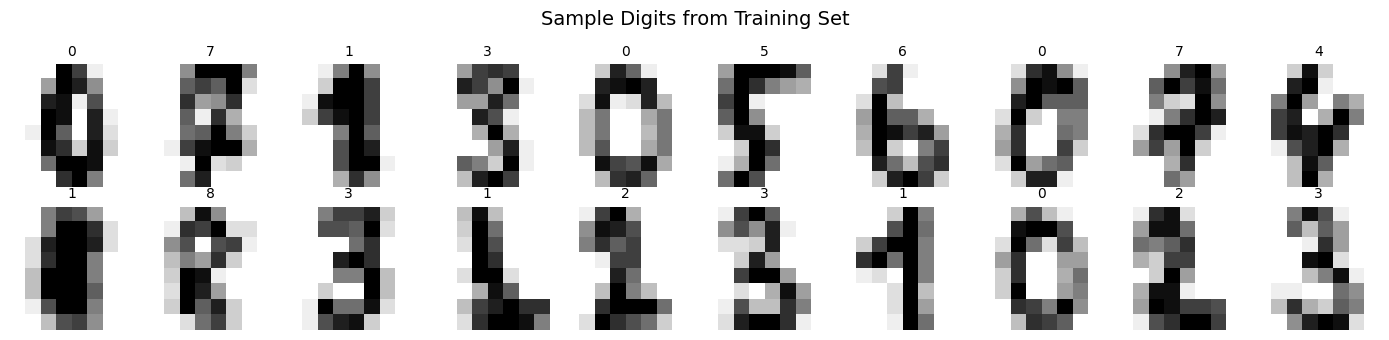

In [5]:
# --- Load and prepare the digits dataset ---
np.random.seed(42)

digits = load_digits()
X_all = digits.data.astype(np.float64)     # shape: (1797, 64)
y_all = digits.target.astype(np.int32)     # shape: (1797,)

print(f'Dataset: {X_all.shape[0]} samples, {X_all.shape[1]} features, {len(np.unique(y_all))} classes')

# Normalize to zero mean, unit variance
scaler = StandardScaler()
X_all = scaler.fit_transform(X_all)

# Split: 70% train, 15% val, 15% test
X_train, X_temp, y_train, y_temp = train_test_split(
    X_all, y_all, test_size=0.30, random_state=42, stratify=y_all)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp)

print(f'Train: {X_train.shape[0]}, Val: {X_val.shape[0]}, Test: {X_test.shape[0]}')

# Show some sample digits
fig, axes = plt.subplots(2, 10, figsize=(14, 3.5))
for i in range(20):
    ax = axes[i // 10, i % 10]
    img = scaler.inverse_transform(X_train[i:i+1]).reshape(8, 8)
    ax.imshow(img, cmap='gray_r', interpolation='nearest')
    ax.set_title(str(y_train[i]), fontsize=10)
    ax.axis('off')
plt.suptitle('Sample Digits from Training Set', fontsize=14)
plt.tight_layout()
plt.show()


Architecture: [64, 128, 64, 10]
Total parameters: 17,226
Training samples: 1257

Epoch   0 | Train Loss: 0.2299  Acc: 0.939 | Val Loss: 0.5020  Acc: 0.896
Epoch  10 | Train Loss: 0.0009  Acc: 1.000 | Val Loss: 0.2516  Acc: 0.970
Epoch  20 | Train Loss: 0.0004  Acc: 1.000 | Val Loss: 0.2577  Acc: 0.967
Epoch  30 | Train Loss: 0.0003  Acc: 1.000 | Val Loss: 0.2611  Acc: 0.967
Epoch  40 | Train Loss: 0.0002  Acc: 1.000 | Val Loss: 0.2644  Acc: 0.967
Epoch  50 | Train Loss: 0.0002  Acc: 1.000 | Val Loss: 0.2672  Acc: 0.967
Epoch  60 | Train Loss: 0.0001  Acc: 1.000 | Val Loss: 0.2696  Acc: 0.967
Epoch  70 | Train Loss: 0.0001  Acc: 1.000 | Val Loss: 0.2714  Acc: 0.967
Epoch  79 | Train Loss: 0.0001  Acc: 1.000 | Val Loss: 0.2730  Acc: 0.967


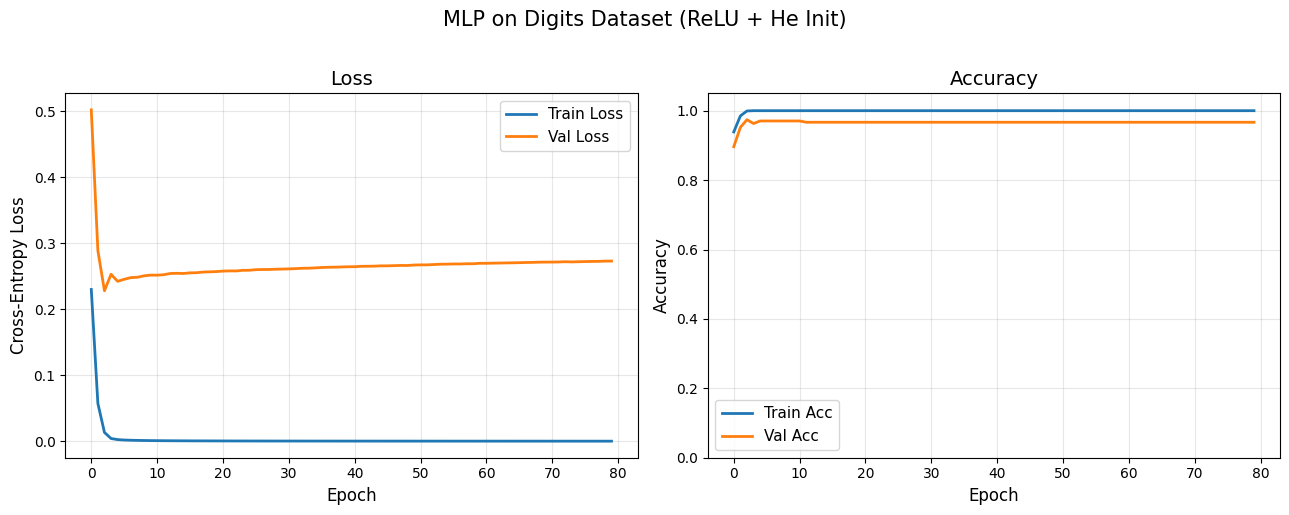


Final Test Accuracy: 0.981


In [6]:
# --- Train our MLP on digits ---
np.random.seed(42)

model_digits = MLP(
    layer_sizes=[64, 128, 64, 10],
    activation='relu',
    init_method='he'
)

print(f'Architecture: {model_digits.layer_sizes}')
print(f'Total parameters: {model_digits.count_params():,}')
print(f'Training samples: {X_train.shape[0]}')
print()

history = train_model(
    model_digits, X_train, y_train, X_val, y_val,
    epochs=80, batch_size=32, lr=0.05, momentum=0.9
)

plot_history(history, title='MLP on Digits Dataset (ReLU + He Init)')

# Final test accuracy
test_preds = model_digits.predict(X_test)
test_acc = np.mean(test_preds == y_test)
print(f'\nFinal Test Accuracy: {test_acc:.3f}')


Our matrix-based MLP achieves strong accuracy on the digits dataset! This is the same kind
of network you built in Notebook 1, but now operating on matrices rather than scalars — much
faster and ready for real data.

Now let's use this framework to run experiments that reveal fundamental truths about neural
network training.


---
## 4. Initialization Experiment

> ### ⑦ **Curriculum Point: Capacity ≠ Performance**
>
> A common misconception: "bigger network = better results." In reality, **how you initialize
> a network matters as much as its architecture.** The same model with the same data can
> either converge beautifully or fail catastrophically depending on weight initialization.
>
> This experiment demonstrates that **capacity (number of parameters) does not determine
> performance** — the initialization scheme, activation function, and training details dominate.

We'll train the **exact same architecture** three times with different initializations:

1. **Naive random** (std = 1.0) — weights are too large
2. **Xavier/Glorot** — designed for sigmoid/tanh (variance = 2/(fan_in + fan_out))
3. **He/Kaiming** — designed for ReLU (variance = 2/fan_in)

All three networks have the same capacity. Only initialization differs.



--- Naive Random (std=1.0) (params: 33,738) ---


/var/folders/sw/fcpngc0n72zdpwblgv65nf3r0000gn/T/ipykernel_98397/2202945264.py:70: RuntimeWarning: overflow encountered in matmul
  z = a @ self.W[l].T + self.b[l]
/var/folders/sw/fcpngc0n72zdpwblgv65nf3r0000gn/T/ipykernel_98397/2202945264.py:70: RuntimeWarning: invalid value encountered in matmul
  z = a @ self.W[l].T + self.b[l]


  Final train acc: 0.099, val acc: 0.100
  Final train loss: nan

--- Xavier/Glorot (params: 33,738) ---
  Final train acc: 1.000, val acc: 0.967
  Final train loss: 0.0000

--- He/Kaiming (params: 33,738) ---
  Final train acc: 1.000, val acc: 0.967
  Final train loss: 0.0000


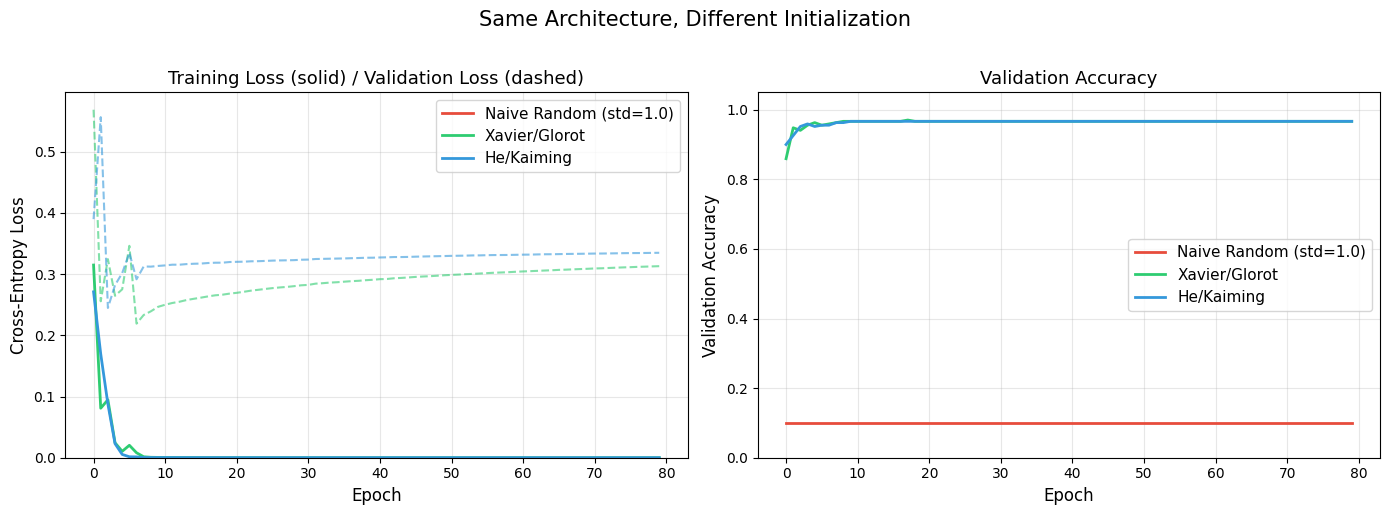


Key Takeaway: Same model capacity, vastly different results.
He init is best for ReLU. Xavier is designed for sigmoid/tanh.
Naive random init (std=1.0) causes the network to struggle or diverge.


In [7]:
# --- Initialization Experiment ---
np.random.seed(42)

arch = [64, 128, 128, 64, 10]  # Same architecture for all three
epochs = 80
lr = 0.05

histories = {}
labels_init = {
    'random': 'Naive Random (std=1.0)',
    'xavier': 'Xavier/Glorot',
    'he':     'He/Kaiming'
}

for init in ['random', 'xavier', 'he']:
    np.random.seed(42)
    model = MLP(arch, activation='relu', init_method=init)
    print(f'\n--- {labels_init[init]} (params: {model.count_params():,}) ---')
    h = train_model(model, X_train, y_train, X_val, y_val,
                    epochs=epochs, batch_size=32, lr=lr, momentum=0.9,
                    verbose=False)

    print(f"  Final train acc: {h['train_acc'][-1]:.3f}, val acc: {h['val_acc'][-1]:.3f}")
    print(f"  Final train loss: {h['train_loss'][-1]:.4f}")
    histories[init] = h

# --- Plot all three on the same axes ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

colors = {'random': '#e74c3c', 'xavier': '#2ecc71', 'he': '#3498db'}

for init in ['random', 'xavier', 'he']:
    h = histories[init]
    ax1.plot(h['train_loss'], color=colors[init], label=labels_init[init], linewidth=2)
    ax1.plot(h['val_loss'], color=colors[init], linestyle='--', alpha=0.6, linewidth=1.5)

ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Cross-Entropy Loss', fontsize=12)
ax1.set_title('Training Loss (solid) / Validation Loss (dashed)', fontsize=13)
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)
ax1.set_ylim(bottom=0)

for init in ['random', 'xavier', 'he']:
    h = histories[init]
    ax2.plot(h['val_acc'], color=colors[init], label=labels_init[init], linewidth=2)

ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('Validation Accuracy', fontsize=12)
ax2.set_title('Validation Accuracy', fontsize=13)
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)
ax2.set_ylim([0, 1.05])

plt.suptitle('Same Architecture, Different Initialization', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

print('\nKey Takeaway: Same model capacity, vastly different results.')
print('He init is best for ReLU. Xavier is designed for sigmoid/tanh.')
print('Naive random init (std=1.0) causes the network to struggle or diverge.')


### What happened?

- **Naive random (std=1.0):** With ReLU activation, large initial weights cause activations
  to explode or many neurons to "die" (permanently output 0). Training struggles.
- **Xavier:** Designed for sigmoid/tanh to keep activation variance stable across layers.
  Works OK with ReLU but isn't optimal.
- **He:** Designed specifically for ReLU, accounting for the fact that ReLU kills half the
  distribution (negative inputs -> 0). The factor of 2/fan_in compensates for this.

> **The lesson: capacity ≠ performance.** A 10,000-parameter model with bad initialization
> can underperform a 1,000-parameter model with good initialization. In deep learning,
> the *recipe* (init, activation, optimizer, learning rate) matters as much as the architecture.


---
## 5. Vanishing Gradients Demo

> ### ⑦ **Curriculum Point: Capacity ≠ Performance** (continued)
>
> Here we show another dramatic way that capacity fails to equal performance: a **deep
> sigmoid network** has enormous capacity in theory, but gradients vanish so badly that
> the early layers barely learn. Swapping sigmoid for ReLU fixes the problem entirely.

Let's build a **10-layer network** and examine gradient magnitudes after one forward + backward
pass. With sigmoid activation, we expect gradients to decay exponentially from output to input.


Architecture: [64, 32, 32, 32, 32, 32, 32, 32, 32, 32, 32, 10]
Depth: 10 hidden layers



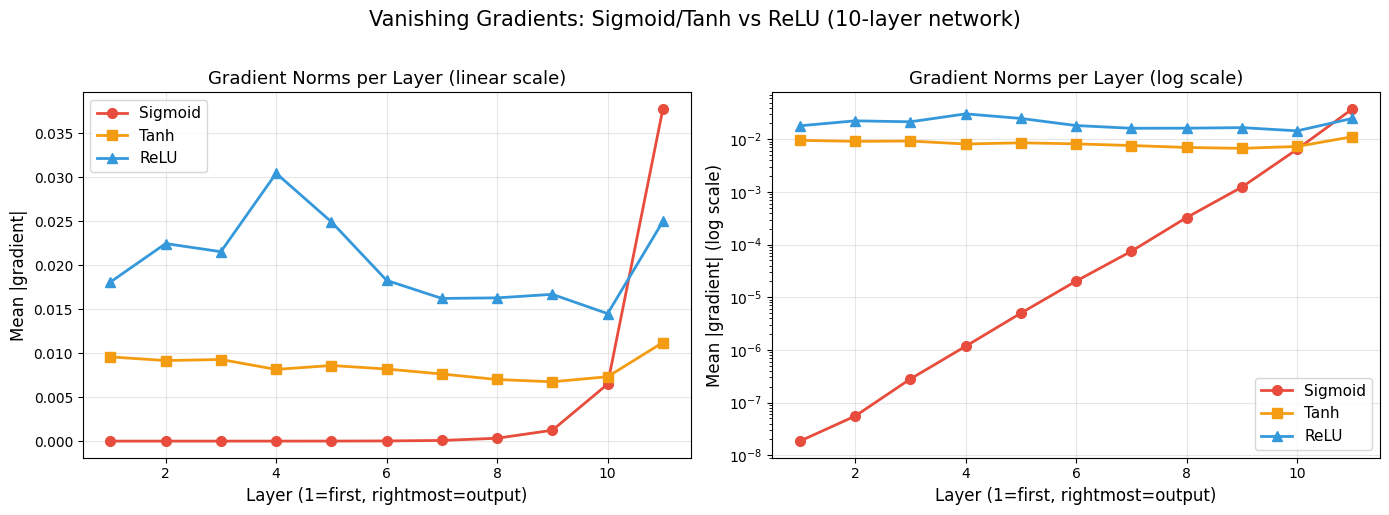

Gradient norms (mean absolute value per layer):
Layer    Sigmoid        Tanh           ReLU          
--------------------------------------------------
1        1.857754e-08   9.571087e-03   1.807352e-02  
2        5.551655e-08   9.152816e-03   2.244640e-02  
3        2.816813e-07   9.273565e-03   2.152431e-02  
4        1.175580e-06   8.146514e-03   3.043407e-02  
5        5.002167e-06   8.591667e-03   2.491338e-02  
6        2.031771e-05   8.194360e-03   1.826430e-02  
7        7.495342e-05   7.625065e-03   1.621168e-02  
8        3.274972e-04   7.001508e-03   1.627931e-02  
9        1.237476e-03   6.741478e-03   1.667819e-02  
10       6.477081e-03   7.319811e-03   1.448803e-02  
11       3.774508e-02   1.120525e-02   2.495965e-02  

First/Last layer gradient ratio:
  Sigmoid: 4.92e-07 (gradients vanished!)
  ReLU:    7.24e-01 (gradients healthy)


In [8]:
# --- Vanishing Gradients Experiment ---
np.random.seed(42)

depth = 10
hidden_size = 32
arch_deep = [64] + [hidden_size] * depth + [10]

print(f'Architecture: {arch_deep}')
print(f'Depth: {depth} hidden layers')
print()

def get_gradient_norms(model, X, y):
    """Do one forward+backward pass and return gradient norms per layer."""
    model.forward(X)
    model.backward(y)
    norms = []
    for l in range(model.num_layers):
        norm = np.sqrt(np.mean(model.grads_W[l] ** 2))
        norms.append(norm)
    return norms

# Use a batch of training data
X_batch = X_train[:128]
y_batch = y_train[:128]

# Sigmoid network
np.random.seed(42)
model_sig = MLP(arch_deep, activation='sigmoid', init_method='xavier')
norms_sig = get_gradient_norms(model_sig, X_batch, y_batch)

# Tanh network
np.random.seed(42)
model_tanh = MLP(arch_deep, activation='tanh', init_method='xavier')
norms_tanh = get_gradient_norms(model_tanh, X_batch, y_batch)

# ReLU network
np.random.seed(42)
model_relu = MLP(arch_deep, activation='relu', init_method='he')
norms_relu = get_gradient_norms(model_relu, X_batch, y_batch)

# --- Plot gradient norms per layer ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

layers = list(range(1, len(norms_sig) + 1))

# Linear scale
ax1.plot(layers, norms_sig, 'o-', color='#e74c3c', label='Sigmoid', linewidth=2, markersize=7)
ax1.plot(layers, norms_tanh, 's-', color='#f39c12', label='Tanh', linewidth=2, markersize=7)
ax1.plot(layers, norms_relu, '^-', color='#3498db', label='ReLU', linewidth=2, markersize=7)
ax1.set_xlabel('Layer (1=first, rightmost=output)', fontsize=12)
ax1.set_ylabel('Mean |gradient|', fontsize=12)
ax1.set_title('Gradient Norms per Layer (linear scale)', fontsize=13)
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)

# Log scale
ax2.semilogy(layers, norms_sig, 'o-', color='#e74c3c', label='Sigmoid', linewidth=2, markersize=7)
ax2.semilogy(layers, norms_tanh, 's-', color='#f39c12', label='Tanh', linewidth=2, markersize=7)
ax2.semilogy(layers, norms_relu, '^-', color='#3498db', label='ReLU', linewidth=2, markersize=7)
ax2.set_xlabel('Layer (1=first, rightmost=output)', fontsize=12)
ax2.set_ylabel('Mean |gradient| (log scale)', fontsize=12)
ax2.set_title('Gradient Norms per Layer (log scale)', fontsize=13)
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)

plt.suptitle('Vanishing Gradients: Sigmoid/Tanh vs ReLU (10-layer network)', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

# Print numerical values
print('Gradient norms (mean absolute value per layer):')
print(f'{"Layer":<8} {"Sigmoid":<14} {"Tanh":<14} {"ReLU":<14}')
print('-' * 50)
for i in range(len(norms_sig)):
    print(f'{i+1:<8} {norms_sig[i]:<14.6e} {norms_tanh[i]:<14.6e} {norms_relu[i]:<14.6e}')

ratio_sig = norms_sig[0] / norms_sig[-1] if norms_sig[-1] > 0 else float('inf')
ratio_relu = norms_relu[0] / norms_relu[-1] if norms_relu[-1] > 0 else float('inf')
print(f'\nFirst/Last layer gradient ratio:')
print(f'  Sigmoid: {ratio_sig:.2e} (gradients vanished!)')
print(f'  ReLU:    {ratio_relu:.2e} (gradients healthy)')


### Why do gradients vanish with sigmoid?

Recall from Section 2.1: the maximum derivative of sigmoid is **0.25** (at z=0).
During backpropagation through 10 layers, gradients get multiplied by this derivative at
each layer. In the worst case:

$$|\text{gradient at layer 1}| \approx |\text{gradient at layer 10}| \times (0.25)^{10} \approx 10^{-6} \times |\text{gradient at layer 10}|$$

The early layers receive gradients that are essentially **zero** — they can't learn!

**ReLU's derivative is either 0 or 1.** For active neurons (input > 0), the gradient passes
through unchanged. This is why "**ReLU changed everything**" for deep learning — it made
training networks with many layers feasible for the first time.

> Even though the sigmoid network has the same capacity (same number of parameters), it
> **cannot use that capacity** because the early layers cannot learn. This is another
> manifestation of **capacity ≠ performance**.


---
## 6. Overparameterization Experiment

> ### ③ **Curriculum Point: Overparameterization Helps**
>
> Classical statistics says: if your model has more parameters than training examples,
> it will **overfit** catastrophically. But modern deep learning routinely violates this rule.
> Networks with millions of parameters trained on thousands of examples often **generalize well**.
>
> This is one of the most surprising and important findings in modern ML theory. The key
> insight: **SGD with momentum has an implicit regularization effect** — it tends to find
> "simple" solutions even when the model could memorize the training data.

Let's demonstrate this directly:
1. Take a **small** subset of data (200 training samples)
2. Train a model with **100x more parameters** than samples
3. Observe: it memorizes the training data perfectly (100% train accuracy)
4. Check: does it also achieve decent test accuracy?


In [9]:
# --- Overparameterization Experiment ---
np.random.seed(42)

# Small subset: 200 training samples
n_small = 200
indices = np.random.choice(X_train.shape[0], n_small, replace=False)
X_small = X_train[indices]
y_small = y_train[indices]

print(f'Training set size: {n_small} samples')
print(f'Input dimension: {X_small.shape[1]}')
print(f'Number of classes: {len(np.unique(y_small))}')
print()

# Regular-sized model (baseline)
np.random.seed(42)
model_regular = MLP([64, 32, 10], activation='relu', init_method='he')
n_params_regular = model_regular.count_params()

# Overparameterized model
np.random.seed(42)
model_overparam = MLP([64, 512, 256, 128, 10], activation='relu', init_method='he')
n_params_overparam = model_overparam.count_params()

print(f'Regular model:        {n_params_regular:>8,} parameters ({n_params_regular/n_small:.1f}x samples)')
print(f'Overparameterized:    {n_params_overparam:>8,} parameters ({n_params_overparam/n_small:.1f}x samples)')
print()

# Train both
print('=== Regular Model ===')
h_regular = train_model(model_regular, X_small, y_small, X_val, y_val,
                        epochs=150, batch_size=32, lr=0.05, momentum=0.9,
                        verbose=False)
print(f"Final -- Train Acc: {h_regular['train_acc'][-1]:.3f}, Val Acc: {h_regular['val_acc'][-1]:.3f}")

print('\n=== Overparameterized Model ===')
h_overparam = train_model(model_overparam, X_small, y_small, X_val, y_val,
                          epochs=150, batch_size=32, lr=0.05, momentum=0.9,
                          verbose=False)
print(f"Final -- Train Acc: {h_overparam['train_acc'][-1]:.3f}, Val Acc: {h_overparam['val_acc'][-1]:.3f}")


Training set size: 200 samples
Input dimension: 64
Number of classes: 10

Regular model:           2,410 parameters (12.1x samples)
Overparameterized:     198,794 parameters (994.0x samples)

=== Regular Model ===
Final -- Train Acc: 1.000, Val Acc: 0.878

=== Overparameterized Model ===
Final -- Train Acc: 1.000, Val Acc: 0.878


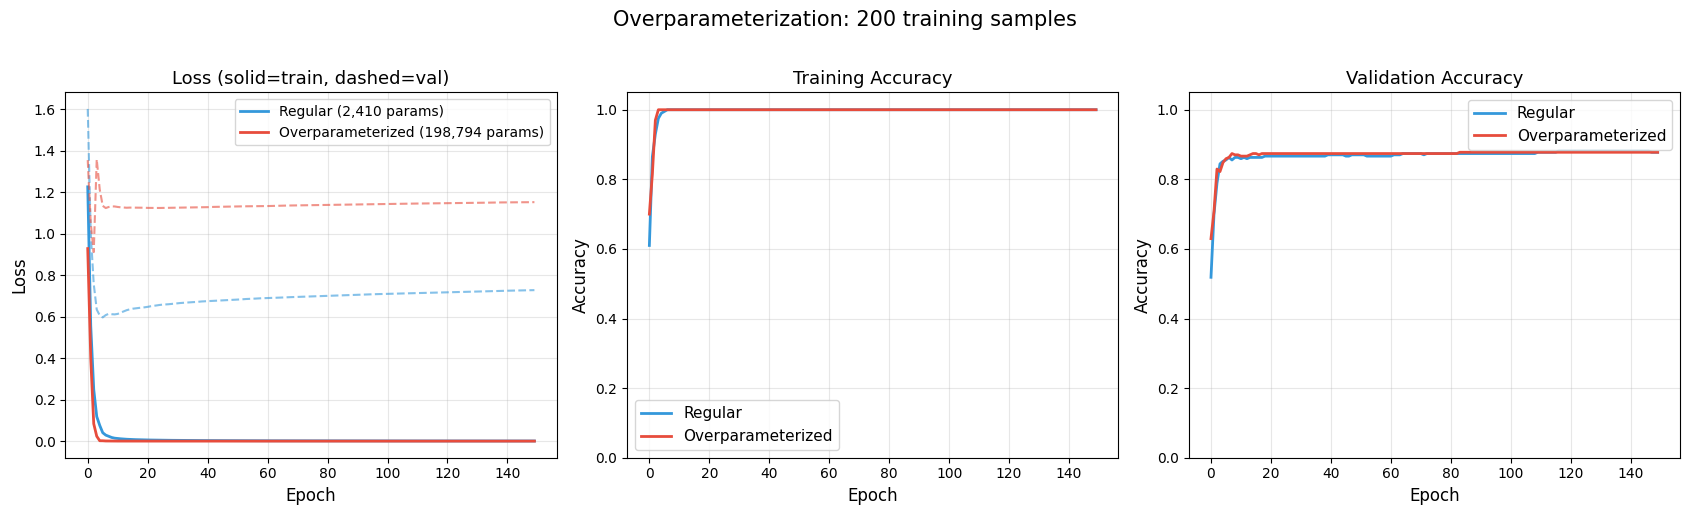

In [10]:
# --- Plot comparison ---
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# Loss
axes[0].plot(h_regular['train_loss'], color='#3498db',
             label=f'Regular ({n_params_regular:,} params)', linewidth=2)
axes[0].plot(h_regular['val_loss'], color='#3498db', linestyle='--', alpha=0.6, linewidth=1.5)
axes[0].plot(h_overparam['train_loss'], color='#e74c3c',
             label=f'Overparameterized ({n_params_overparam:,} params)', linewidth=2)
axes[0].plot(h_overparam['val_loss'], color='#e74c3c', linestyle='--', alpha=0.6, linewidth=1.5)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss', fontsize=12)
axes[0].set_title('Loss (solid=train, dashed=val)', fontsize=13)
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# Training accuracy
axes[1].plot(h_regular['train_acc'], color='#3498db', label='Regular', linewidth=2)
axes[1].plot(h_overparam['train_acc'], color='#e74c3c', label='Overparameterized', linewidth=2)
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Accuracy', fontsize=12)
axes[1].set_title('Training Accuracy', fontsize=13)
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)
axes[1].set_ylim([0, 1.05])

# Validation accuracy
axes[2].plot(h_regular['val_acc'], color='#3498db', label='Regular', linewidth=2)
axes[2].plot(h_overparam['val_acc'], color='#e74c3c', label='Overparameterized', linewidth=2)
axes[2].set_xlabel('Epoch', fontsize=12)
axes[2].set_ylabel('Accuracy', fontsize=12)
axes[2].set_title('Validation Accuracy', fontsize=13)
axes[2].legend(fontsize=11)
axes[2].grid(True, alpha=0.3)
axes[2].set_ylim([0, 1.05])

plt.suptitle(f'Overparameterization: {n_small} training samples', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()


### The Surprise

The overparameterized model (with far more parameters than training samples) achieves **near-perfect
training accuracy** — it effectively memorizes the training set. But it *also* achieves
competitive validation accuracy!

**Classical statistics says this shouldn't work.** A model with N parameters and N/10 data points
should overfit terribly. Yet in practice, overparameterized neural networks trained with SGD
often generalize well.

### Why?

This is an active area of research, but the key insight is **implicit regularization**:

1. **SGD doesn't find arbitrary solutions** — it has an inductive bias toward "simple"
   (low-norm) solutions due to the dynamics of gradient descent.
2. **Momentum helps** — it smooths the optimization trajectory, favoring flatter regions
   of the loss landscape.
3. **The loss landscape of overparameterized networks has favorable geometry** — there are
   many global minima, and SGD tends to find ones that generalize.

This is deeply connected to the **double descent** phenomenon: test error first increases
(classical regime), then decreases again (modern interpolation regime) as model size grows
past the interpolation threshold.


---
## 7. Loss Landscape Visualization

> ### ⑥ **Curriculum Point: Geometry Matters**
>
> The loss landscape — the function $\mathcal{L}(\theta)$ over the space of all possible
> weight configurations — has fascinating geometry in high dimensions. Its structure
> determines whether training succeeds or fails, and whether the solution generalizes.
>
> Key ideas:
> - **Flat minima** tend to generalize better (robust to small weight perturbations)
> - **Sharp minima** tend to generalize poorly (sensitive to perturbations)
> - In high dimensions, most critical points are **saddle points**, not local minima
> - SGD with large learning rates / momentum acts as an implicit regularizer by avoiding sharp minima

We'll visualize a 2D slice of the loss landscape by:
1. Taking the trained weights as a center point
2. Choosing 2 random directions in weight space
3. Evaluating the loss along a grid in these 2 directions


In [11]:
# --- Loss Landscape Visualization ---
np.random.seed(42)

def flatten_params(model):
    """Flatten all model parameters into a single 1D array."""
    return np.concatenate([w.ravel() for w in model.W] + [b.ravel() for b in model.b])

def unflatten_params(model, flat):
    """Restore model parameters from a flattened array."""
    idx = 0
    for l in range(model.num_layers):
        size_w = model.W[l].size
        model.W[l] = flat[idx:idx + size_w].reshape(model.W[l].shape)
        idx += size_w
    for l in range(model.num_layers):
        size_b = model.b[l].size
        model.b[l] = flat[idx:idx + size_b].reshape(model.b[l].shape)
        idx += size_b

def compute_loss_landscape(model, X, y, n_points=31, range_scale=1.0):
    """Compute loss on a 2D grid around current parameters."""
    theta_star = flatten_params(model).copy()
    n_params = theta_star.shape[0]

    # Two random directions, normalized
    d1 = np.random.randn(n_params)
    d2 = np.random.randn(n_params)
    d1 = d1 / np.linalg.norm(d1) * np.linalg.norm(theta_star)
    d2 = d2 / np.linalg.norm(d2) * np.linalg.norm(theta_star)

    alphas = np.linspace(-range_scale, range_scale, n_points)
    betas = np.linspace(-range_scale, range_scale, n_points)
    loss_grid = np.zeros((n_points, n_points))

    for i, alpha in enumerate(alphas):
        for j, beta in enumerate(betas):
            theta = theta_star + alpha * d1 + beta * d2
            unflatten_params(model, theta)
            probs = model.forward(X)
            loss_grid[i, j] = cross_entropy_loss(probs, y)

    # Restore original parameters
    unflatten_params(model, theta_star)
    return alphas, betas, loss_grid


# Train a fresh model for landscape visualization
np.random.seed(42)
model_landscape = MLP([64, 128, 64, 10], activation='relu', init_method='he')
h_land = train_model(model_landscape, X_train, y_train, X_val, y_val,
                     epochs=80, batch_size=32, lr=0.05, momentum=0.9, verbose=False)

print(f"Trained model -- Val Acc: {h_land['val_acc'][-1]:.3f}")
print('Computing loss landscape (this may take a moment)...')

# Use a subset for speed
X_land = X_val[:200]
y_land = y_val[:200]

alphas, betas, loss_grid = compute_loss_landscape(
    model_landscape, X_land, y_land, n_points=31, range_scale=0.5
)
print('Done!')


Trained model -- Val Acc: 0.967
Computing loss landscape (this may take a moment)...
Done!


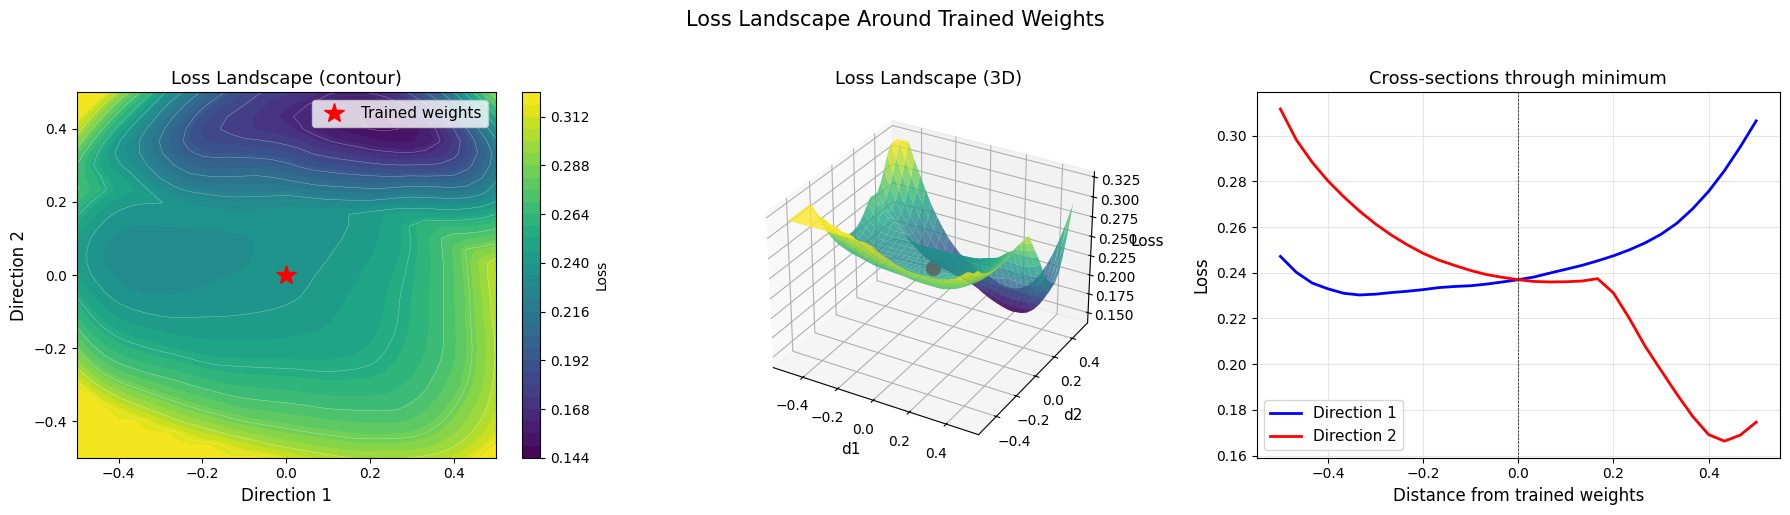

In [12]:
# --- Plot the loss landscape ---
fig = plt.figure(figsize=(18, 5))

# 1. Contour plot
ax1 = fig.add_subplot(131)
A, B = np.meshgrid(alphas, betas)
loss_clipped = np.clip(loss_grid, 0, np.percentile(loss_grid, 95))

cf = ax1.contourf(A, B, loss_clipped.T, levels=30, cmap='viridis')
ax1.contour(A, B, loss_clipped.T, levels=15, colors='white', linewidths=0.3, alpha=0.5)
ax1.plot(0, 0, 'r*', markersize=15, label='Trained weights')
plt.colorbar(cf, ax=ax1, label='Loss')
ax1.set_xlabel('Direction 1', fontsize=12)
ax1.set_ylabel('Direction 2', fontsize=12)
ax1.set_title('Loss Landscape (contour)', fontsize=13)
ax1.legend(fontsize=11)

# 2. 3D surface
from mpl_toolkits.mplot3d import Axes3D
ax3d = fig.add_subplot(132, projection='3d')
ax3d.plot_surface(A, B, loss_clipped.T, cmap='viridis', alpha=0.8, edgecolors='none')
center = len(alphas) // 2
ax3d.scatter([0], [0], [loss_grid[center, center]], color='red', s=100, zorder=5)
ax3d.set_xlabel('d1', fontsize=11)
ax3d.set_ylabel('d2', fontsize=11)
ax3d.set_zlabel('Loss', fontsize=11)
ax3d.set_title('Loss Landscape (3D)', fontsize=13)

# 3. Cross-section
ax3 = fig.add_subplot(133)
ax3.plot(alphas, loss_grid[:, center], 'b-', linewidth=2, label='Direction 1')
ax3.plot(betas, loss_grid[center, :], 'r-', linewidth=2, label='Direction 2')
ax3.axvline(0, color='k', linewidth=0.5, linestyle='--')
ax3.set_xlabel('Distance from trained weights', fontsize=12)
ax3.set_ylabel('Loss', fontsize=12)
ax3.set_title('Cross-sections through minimum', fontsize=13)
ax3.legend(fontsize=11)
ax3.grid(True, alpha=0.3)

plt.suptitle('Loss Landscape Around Trained Weights', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()


### Reading the Loss Landscape

What we see:
- The **trained weights** (red star) sit near the bottom of a valley
- The landscape is **not perfectly symmetric** — some directions are steeper than others
- The cross-sections reveal **flat regions** around the minimum, which is good for generalization

### Why Flat Minima Generalize Better

Imagine two models that achieve the same training loss:
- **Model A** sits in a **sharp minimum**: a tiny perturbation to the weights causes the loss
  to spike. Since test data is slightly different from training data, this model will perform
  poorly on test data.
- **Model B** sits in a **flat minimum**: small perturbations barely change the loss. The
  model is robust to the distribution shift between train and test data.

SGD with momentum and a reasonable learning rate tends to find flat minima because:
1. The inherent noise in mini-batch gradients "bounces" the trajectory out of sharp minima
2. Momentum carries the optimizer through narrow valleys
3. Larger learning rates increase this effect (this is one reason learning rate warmup helps)

> **Geometry matters:** The shape of the loss landscape in the neighborhood of a solution
> tells us more about generalization than the loss value itself.


### Flat vs Sharp Minima: Learning Rate Experiment

Large learning rates tend to find flat minima. Small learning rates can get trapped in sharp ones.
Let's verify this empirically by comparing the "sharpness" (curvature) of solutions found
with different learning rates.


LR=0.001 -> Val Acc: 0.948, Sharpness: -0.0000 +/- 0.0015
LR=0.010 -> Val Acc: 0.970, Sharpness: -0.0001 +/- 0.0013
LR=0.050 -> Val Acc: 0.967, Sharpness: 0.0002 +/- 0.0008
LR=0.100 -> Val Acc: 0.193, Sharpness: 0.0005 +/- 0.0029


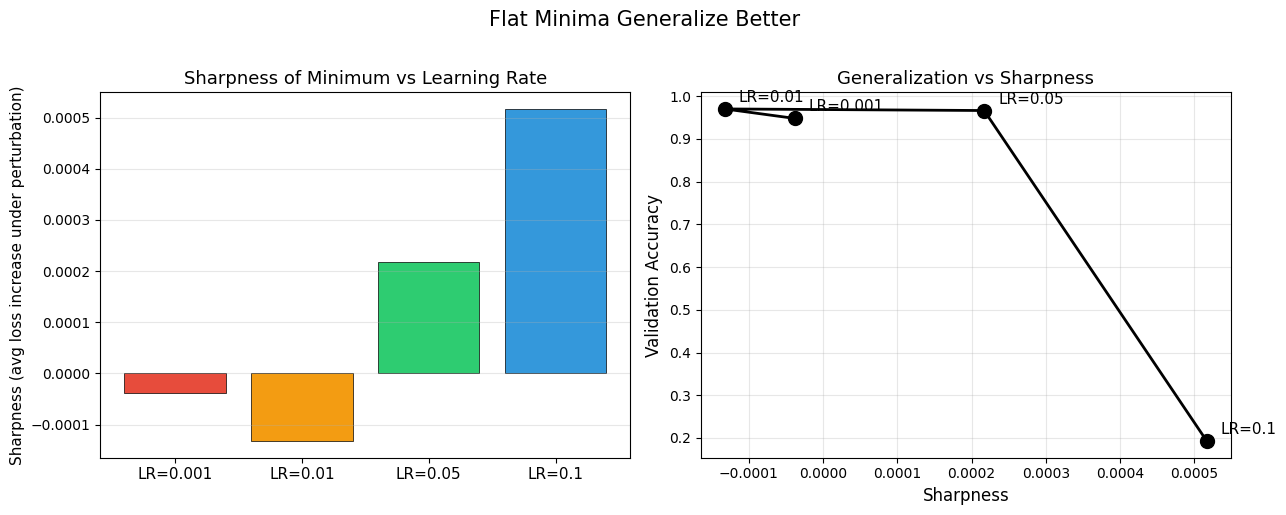


Trend: lower sharpness (flatter minimum) tends to correlate with better generalization.


In [13]:
# --- Sharpness measurement ---
np.random.seed(42)

def measure_sharpness(model, X, y, n_perturbations=50, epsilon=0.01):
    """
    Measure sharpness: average increase in loss when we perturb weights.
    Higher sharpness = sharper minimum = worse expected generalization.
    """
    theta_star = flatten_params(model).copy()
    base_probs = model.forward(X)
    base_loss = cross_entropy_loss(base_probs, y)

    loss_increases = []
    for _ in range(n_perturbations):
        perturbation = np.random.randn(theta_star.shape[0])
        perturbation = perturbation / np.linalg.norm(perturbation) * epsilon * np.linalg.norm(theta_star)
        unflatten_params(model, theta_star + perturbation)
        probs = model.forward(X)
        perturbed_loss = cross_entropy_loss(probs, y)
        loss_increases.append(perturbed_loss - base_loss)

    unflatten_params(model, theta_star)
    return np.mean(loss_increases), np.std(loss_increases)


learning_rates = [0.001, 0.01, 0.05, 0.1]
sharpness_results = []

for lr_val in learning_rates:
    np.random.seed(42)
    m = MLP([64, 128, 64, 10], activation='relu', init_method='he')
    h = train_model(m, X_train, y_train, X_val, y_val,
                    epochs=80, batch_size=32, lr=lr_val, momentum=0.9, verbose=False)
    sharp_mean, sharp_std = measure_sharpness(m, X_val, y_val)
    val_acc = h['val_acc'][-1]
    sharpness_results.append((lr_val, sharp_mean, sharp_std, val_acc))
    print(f'LR={lr_val:.3f} -> Val Acc: {val_acc:.3f}, Sharpness: {sharp_mean:.4f} +/- {sharp_std:.4f}')

# Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

lrs = [r[0] for r in sharpness_results]
sharps = [r[1] for r in sharpness_results]
accs = [r[3] for r in sharpness_results]

ax1.bar(range(len(lrs)), sharps, color=['#e74c3c', '#f39c12', '#2ecc71', '#3498db'],
        edgecolor='black', linewidth=0.5)
ax1.set_xticks(range(len(lrs)))
ax1.set_xticklabels([f'LR={lr}' for lr in lrs], fontsize=11)
ax1.set_ylabel('Sharpness (avg loss increase under perturbation)', fontsize=11)
ax1.set_title('Sharpness of Minimum vs Learning Rate', fontsize=13)
ax1.grid(True, alpha=0.3, axis='y')

ax2.plot(sharps, accs, 'ko-', markersize=10, linewidth=2)
for i, lr_val in enumerate(lrs):
    ax2.annotate(f'LR={lr_val}', (sharps[i], accs[i]),
                textcoords='offset points', xytext=(10, 5), fontsize=11)
ax2.set_xlabel('Sharpness', fontsize=12)
ax2.set_ylabel('Validation Accuracy', fontsize=12)
ax2.set_title('Generalization vs Sharpness', fontsize=13)
ax2.grid(True, alpha=0.3)

plt.suptitle('Flat Minima Generalize Better', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

print('\nTrend: lower sharpness (flatter minimum) tends to correlate with better generalization.')


---
## 8. Exercises

### Exercise 1: Learning Rate Finder

Implement a simple learning rate finder:
1. Start with a very small learning rate (e.g., 1e-5)
2. Train for one epoch, doubling the LR after each batch
3. Record the loss at each LR
4. Plot loss vs LR — the optimal LR is just before the loss starts increasing

This technique (from Leslie Smith's 2017 paper) is widely used in practice.


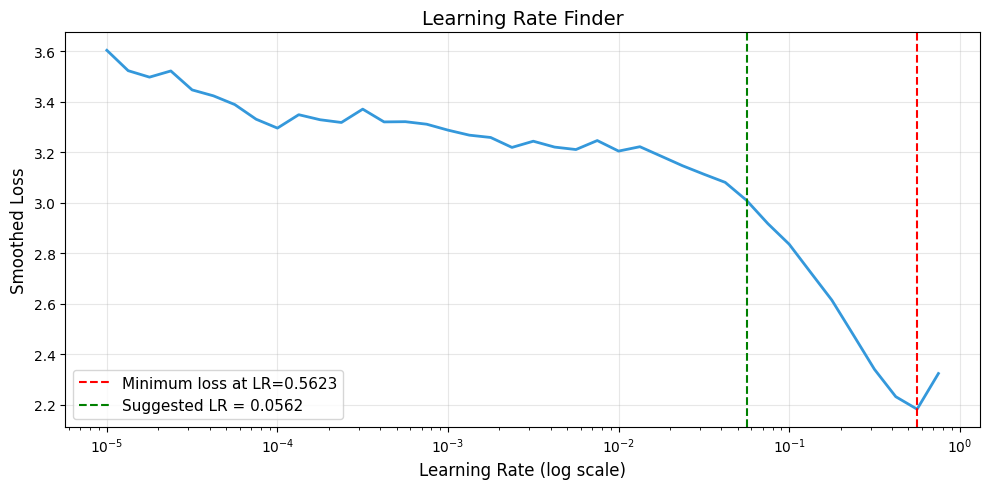

Best loss at LR = 0.56234
Suggested LR = 0.05623 (typically 10x smaller than the minimum)


In [14]:
# --- Exercise 1: Learning Rate Finder ---
# SOLUTION

np.random.seed(42)

model_lrf = MLP([64, 128, 64, 10], activation='relu', init_method='he')

# LR range: 1e-5 to 1.0, logarithmically spaced
lr_min, lr_max = 1e-5, 1.0
n_batches_total = (X_train.shape[0] + 31) // 32
lr_mult = (lr_max / lr_min) ** (1.0 / n_batches_total)

lrs_recorded = []
losses_recorded = []
current_lr = lr_min

# One pass through the training data
perm = np.random.permutation(X_train.shape[0])
X_shuffled = X_train[perm]
y_shuffled = y_train[perm]

smoothed_loss = None
best_loss = float('inf')

for start in range(0, X_train.shape[0], 32):
    end = min(start + 32, X_train.shape[0])
    X_b = X_shuffled[start:end]
    y_b = y_shuffled[start:end]

    probs = model_lrf.forward(X_b)
    loss = cross_entropy_loss(probs, y_b)

    # Exponential smoothing
    if smoothed_loss is None:
        smoothed_loss = loss
    else:
        smoothed_loss = 0.9 * smoothed_loss + 0.1 * loss

    lrs_recorded.append(current_lr)
    losses_recorded.append(smoothed_loss)

    # Stop if loss is diverging
    if smoothed_loss < best_loss:
        best_loss = smoothed_loss
    if smoothed_loss > 4 * best_loss:
        break

    model_lrf.backward(y_b)
    # Use no momentum for cleaner signal
    for l_idx in range(model_lrf.num_layers):
        model_lrf.W[l_idx] -= current_lr * model_lrf.grads_W[l_idx]
        model_lrf.b[l_idx] -= current_lr * model_lrf.grads_b[l_idx]

    current_lr *= lr_mult

# Plot
fig, ax = plt.subplots(figsize=(10, 5))
ax.semilogx(lrs_recorded, losses_recorded, linewidth=2, color='#3498db')
ax.set_xlabel('Learning Rate (log scale)', fontsize=12)
ax.set_ylabel('Smoothed Loss', fontsize=12)
ax.set_title('Learning Rate Finder', fontsize=14)
ax.grid(True, alpha=0.3)

# Find the LR at minimum loss
best_idx = np.argmin(losses_recorded)
ax.axvline(lrs_recorded[best_idx], color='red', linestyle='--',
           label=f'Minimum loss at LR={lrs_recorded[best_idx]:.4f}')
suggested_lr = lrs_recorded[best_idx] / 10
ax.axvline(suggested_lr, color='green', linestyle='--',
           label=f'Suggested LR = {suggested_lr:.4f}')
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

print(f'Best loss at LR = {lrs_recorded[best_idx]:.5f}')
print(f'Suggested LR = {suggested_lr:.5f} (typically 10x smaller than the minimum)')


### Exercise 2: Implement Learning Rate Scheduling

Implement a **cosine annealing** learning rate schedule:

$$\text{lr}(t) = \text{lr}_{\min} + \frac{1}{2}(\text{lr}_{\max} - \text{lr}_{\min})\left(1 + \cos\left(\frac{t}{T}\pi\right)\right)$$

Train a model with cosine annealing and compare the training curve to constant LR.


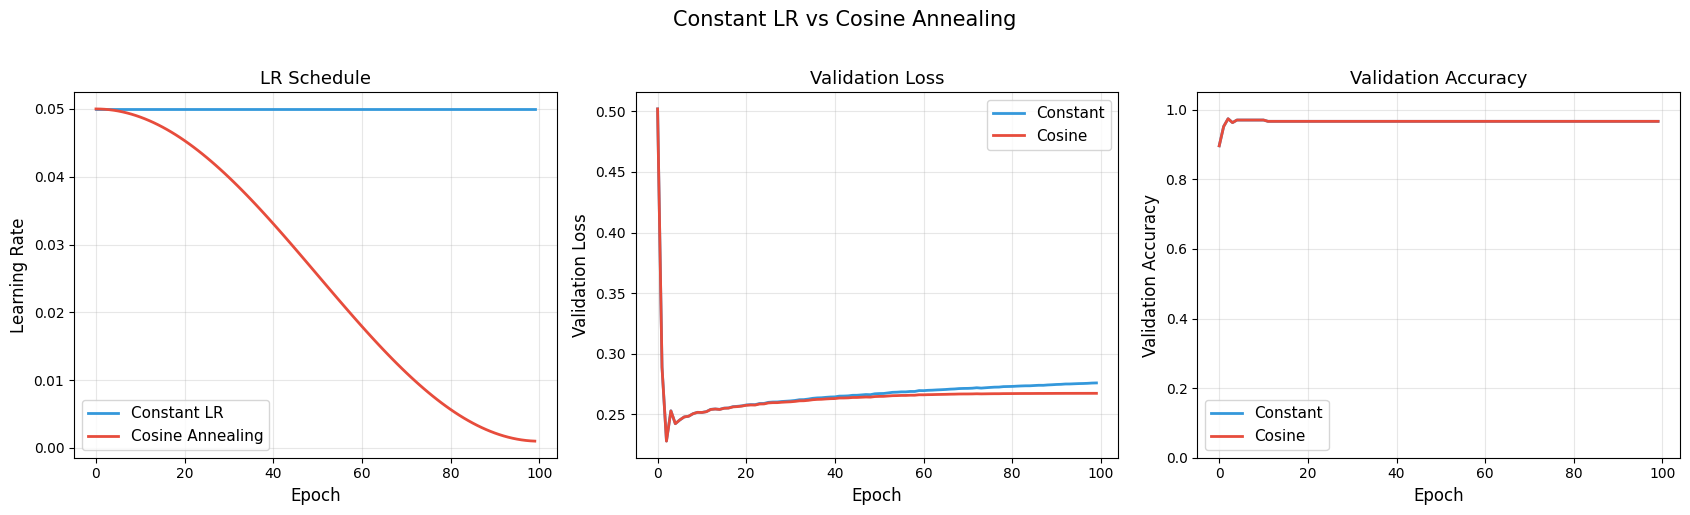

Constant LR -- Final Val Acc: 0.967
Cosine Annealing -- Final Val Acc: 0.967

Cosine annealing gradually reduces the learning rate, allowing the optimizer
to fine-tune its solution in the later stages of training.


In [15]:
# --- Exercise 2: Cosine Annealing LR Schedule ---
# SOLUTION

def cosine_lr(epoch, total_epochs, lr_max=0.05, lr_min=0.001):
    """Cosine annealing schedule."""
    return lr_min + 0.5 * (lr_max - lr_min) * (1 + np.cos(np.pi * epoch / total_epochs))


def train_with_schedule(model, X_train, y_train, X_val, y_val,
                        epochs=100, batch_size=32, lr_fn=None, momentum=0.9):
    """Train with a learning rate schedule function."""
    n_train = X_train.shape[0]
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': [], 'lr': []}

    for epoch in range(epochs):
        lr = lr_fn(epoch, epochs) if lr_fn else 0.05
        history['lr'].append(lr)

        perm = np.random.permutation(n_train)
        X_s = X_train[perm]
        y_s = y_train[perm]

        for start in range(0, n_train, batch_size):
            end = min(start + batch_size, n_train)
            probs = model.forward(X_s[start:end])
            model.backward(y_s[start:end])
            model.step(lr=lr, momentum=momentum)

        # Metrics
        tp = model.predict(X_train)
        tr_probs = model.forward(X_train)
        vp = model.predict(X_val)
        vl_probs = model.forward(X_val)

        history['train_loss'].append(cross_entropy_loss(tr_probs, y_train))
        history['val_loss'].append(cross_entropy_loss(vl_probs, y_val))
        history['train_acc'].append(np.mean(tp == y_train))
        history['val_acc'].append(np.mean(vp == y_val))

    return history


np.random.seed(42)
epochs_sched = 100

# Constant LR
np.random.seed(42)
model_const = MLP([64, 128, 64, 10], activation='relu', init_method='he')
h_const = train_with_schedule(model_const, X_train, y_train, X_val, y_val,
                              epochs=epochs_sched,
                              lr_fn=lambda e, T: 0.05)

# Cosine annealing
np.random.seed(42)
model_cosine = MLP([64, 128, 64, 10], activation='relu', init_method='he')
h_cosine = train_with_schedule(model_cosine, X_train, y_train, X_val, y_val,
                               epochs=epochs_sched,
                               lr_fn=cosine_lr)

# Plot
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

axes[0].plot(h_const['lr'], label='Constant LR', linewidth=2, color='#3498db')
axes[0].plot(h_cosine['lr'], label='Cosine Annealing', linewidth=2, color='#e74c3c')
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Learning Rate', fontsize=12)
axes[0].set_title('LR Schedule', fontsize=13)
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

axes[1].plot(h_const['val_loss'], label='Constant', linewidth=2, color='#3498db')
axes[1].plot(h_cosine['val_loss'], label='Cosine', linewidth=2, color='#e74c3c')
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Validation Loss', fontsize=12)
axes[1].set_title('Validation Loss', fontsize=13)
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

axes[2].plot(h_const['val_acc'], label='Constant', linewidth=2, color='#3498db')
axes[2].plot(h_cosine['val_acc'], label='Cosine', linewidth=2, color='#e74c3c')
axes[2].set_xlabel('Epoch', fontsize=12)
axes[2].set_ylabel('Validation Accuracy', fontsize=12)
axes[2].set_title('Validation Accuracy', fontsize=13)
axes[2].legend(fontsize=11)
axes[2].grid(True, alpha=0.3)
axes[2].set_ylim([0, 1.05])

plt.suptitle('Constant LR vs Cosine Annealing', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

print(f"Constant LR -- Final Val Acc: {h_const['val_acc'][-1]:.3f}")
print(f"Cosine Annealing -- Final Val Acc: {h_cosine['val_acc'][-1]:.3f}")
print('\nCosine annealing gradually reduces the learning rate, allowing the optimizer')
print('to fine-tune its solution in the later stages of training.')


### Exercise 3: Batch Size Effects

Train the same model with batch sizes of 8, 32, 128, and the full dataset. Compare:
- Training speed (loss per epoch)
- Final generalization (validation accuracy)
- Gradient noise (measure variance of loss across batches)

**Hypothesis**: Small batches = more noise = better generalization but slower convergence.
Large batches = less noise = faster convergence but potentially worse generalization.


/var/folders/sw/fcpngc0n72zdpwblgv65nf3r0000gn/T/ipykernel_98397/4007798829.py:53: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


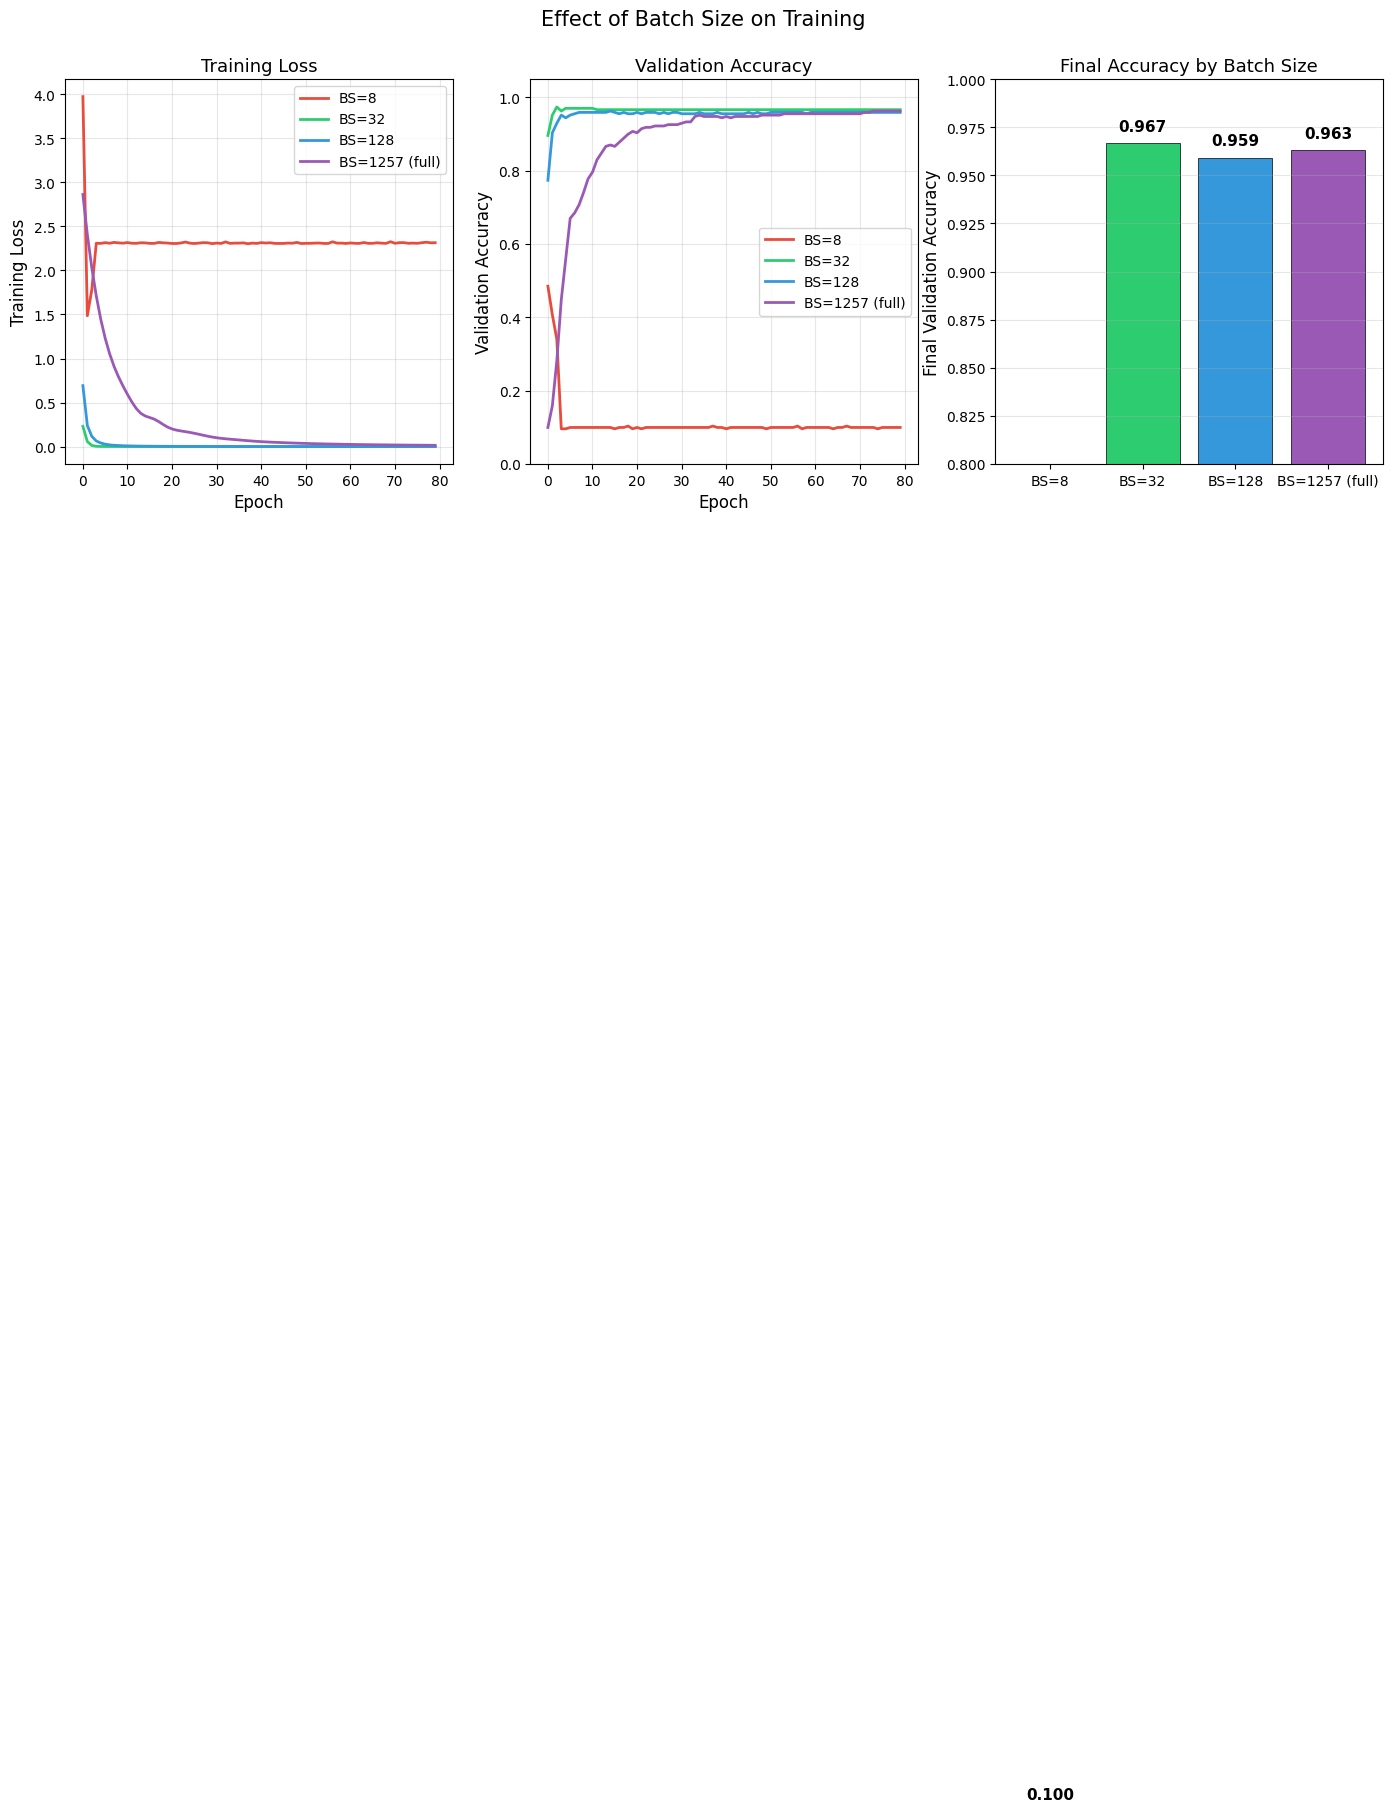

Observations:
- Small batches: noisier gradients, but the noise can help escape sharp minima
- Large batches: smoother convergence, but may get stuck in sharp minima
- In practice, batch size is a key hyperparameter that interacts with learning rate
  (often: if you double batch size, double the learning rate)


In [16]:
# --- Exercise 3: Batch Size Effects ---
# SOLUTION

np.random.seed(42)

batch_sizes = [8, 32, 128, X_train.shape[0]]
batch_labels = ['8', '32', '128', f'{X_train.shape[0]} (full)']
batch_colors = ['#e74c3c', '#2ecc71', '#3498db', '#9b59b6']
batch_histories = []

for bs in batch_sizes:
    np.random.seed(42)
    m = MLP([64, 128, 64, 10], activation='relu', init_method='he')
    h = train_model(m, X_train, y_train, X_val, y_val,
                    epochs=80, batch_size=bs, lr=0.05, momentum=0.9, verbose=False)
    batch_histories.append(h)

# Plot
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

for i, (bs_label, h, color) in enumerate(zip(batch_labels, batch_histories, batch_colors)):
    axes[0].plot(h['train_loss'], label=f'BS={bs_label}', linewidth=2, color=color)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Training Loss', fontsize=12)
axes[0].set_title('Training Loss', fontsize=13)
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

for i, (bs_label, h, color) in enumerate(zip(batch_labels, batch_histories, batch_colors)):
    axes[1].plot(h['val_acc'], label=f'BS={bs_label}', linewidth=2, color=color)
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Validation Accuracy', fontsize=12)
axes[1].set_title('Validation Accuracy', fontsize=13)
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)
axes[1].set_ylim([0, 1.05])

# Final accuracy comparison
final_accs = [h['val_acc'][-1] for h in batch_histories]
bars = axes[2].bar(range(len(batch_sizes)), final_accs, color=batch_colors,
                   edgecolor='black', linewidth=0.5)
axes[2].set_xticks(range(len(batch_sizes)))
axes[2].set_xticklabels([f'BS={l}' for l in batch_labels], fontsize=10)
axes[2].set_ylabel('Final Validation Accuracy', fontsize=12)
axes[2].set_title('Final Accuracy by Batch Size', fontsize=13)
axes[2].grid(True, alpha=0.3, axis='y')
axes[2].set_ylim([0.8, 1.0])
for bar, acc in zip(bars, final_accs):
    axes[2].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.005,
                f'{acc:.3f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.suptitle('Effect of Batch Size on Training', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

print('Observations:')
print('- Small batches: noisier gradients, but the noise can help escape sharp minima')
print('- Large batches: smoother convergence, but may get stuck in sharp minima')
print('- In practice, batch size is a key hyperparameter that interacts with learning rate')
print('  (often: if you double batch size, double the learning rate)')


---
## Summary

In this notebook, we built a complete matrix-based neural network from scratch in NumPy and
used it to explore three fundamental aspects of training dynamics:

### Key Curriculum Points

> **③ Overparameterization Helps:** Models with far more parameters than training samples
> can still generalize, thanks to the implicit regularization of SGD. This challenges
> classical statistical learning theory.

> **⑥ Geometry Matters:** The loss landscape determines training success. Flat minima
> generalize better than sharp ones. SGD with momentum naturally favors flat minima due to
> gradient noise. The learning rate, batch size, and momentum all influence which minimum
> the optimizer finds.

> **⑦ Capacity ≠ Performance:** Having more parameters doesn't guarantee better results.
> Initialization (He vs Xavier vs naive), activation function choice, learning rate,
> and optimizer details dominate raw model capacity.

### What's Next?

In **Notebook 3** (Generative Models from Scratch), we'll build on these foundations to
create models that can *generate* new data — character-level language models and autoencoders
— still in pure Python/NumPy.
